# Quantitative Trading Strategy Development  
## Step 05 — Regime Detection

Objective:  
Identify latent market regimes using engineered features to enable
regime-aware trading strategies.


## Pipeline Context

This notebook follows the feature engineering stage and identifies
hidden market states from historical data.

Pipeline sequence:

1. Data Validation  
2. Data Cleaning  
3. Data Merging  
4. Feature Engineering  
5. Regime Detection (current step)  
6. Strategy Backtesting  
7. Machine Learning Enhancement  
8. Outlier Analysis  


In [2]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

PLOTS_DIR = "../plots"
RESULTS_DIR = "../results"

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [9]:
from src.data_io import load_csv
from src.regime import RegimeModel
import os


## Purpose of Regime Detection

Financial markets exhibit changing behavior over time such as:

- trending periods  
- mean-reverting phases  
- high-volatility conditions  

Regime detection allows strategies to adapt to these structural shifts
rather than relying on static rules.


## Loading Feature Dataset

The feature-engineered dataset generated in the previous step is used
as input for regime modeling.


In [10]:
df = load_csv('data/processed/nifty_features_5min.csv')
df = df.dropna()

Loaded 126 rows from c:\Users\Tushar Mathur\Downloads\Quantitative_Trading_Strategy_Development\Quantitative_Trading_Strategy_Development\data/processed/nifty_features_5min.csv


## Feature Selection

A subset of features is selected to represent market dynamics for
regime inference.


In [11]:
feats = ['avg_iv', 'iv_spread', 'ema_5']

## Feature Validation

Selected features are verified for availability before training.
If required features are missing, fallback features are used to
ensure model robustness.


In [19]:
valid_feats = [f for f in feats if f in df.columns]
if not valid_feats:
    print('Warning: No features for regime. Using returns.')
    valid_feats = ['returns']
X = df[valid_feats].values

## Regime Model Training

A Hidden Markov Model is trained on the selected features to infer
latent market regimes.


In [20]:
model = RegimeModel()

In [23]:
model.fit(X[:int(0.7*len(X))])
regimes = model.predict(X)
import pandas as pd
pd.Series(regimes).value_counts()

Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'
Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'
c:\Users\Tushar Mathur\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'


0    16
1    15
Name: count, dtype: int64

## Saving Regime Model

The trained regime model is saved for reuse during strategy backtesting.


In [24]:
os.makedirs('../models', exist_ok=True)
model.save('../models/regime_hmm.joblib')
print('Saved regime model')

Saved regime model


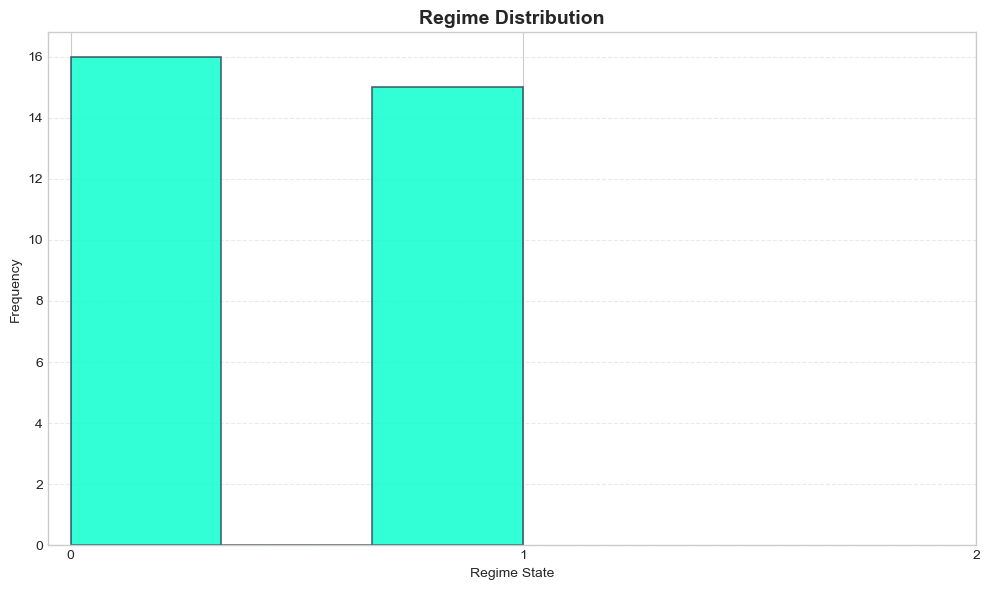

In [25]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")  

regimes = model.predict(X)

plt.figure(figsize=(10, 6))
plt.hist(
    regimes,
    bins=3,
    alpha=0.8,
    color="#00ffcc",
    edgecolor="#2C3E50",
    linewidth=1.2
)

plt.title("Regime Distribution", fontsize=14, weight="bold")
plt.xlabel("Regime State")
plt.ylabel("Frequency")

plt.xticks([0, 1, 2])
plt.grid(axis='y', linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/regime_distribution.png", dpi=300)
plt.show()
plt.close()
